# Principal Component Analysis (PCA) From Scratch

This notebook derives and implements PCA step-by-step using linear algebra.

We will:

- Derive PCA from variance maximization
- Compute covariance matrix
- Perform eigen-decomposition
- Project data to lower dimension
- Reconstruct original data
- Connect PCA to SVD
- Analyze explained variance

## Mathematical Objective of PCA

Given centered data matrix:

X ∈ ℝ^{n × d}

PCA solves:

max_w   wᵀ Σ w  
subject to  ||w|| = 1

Where:

Σ = (1/n-1) XᵀX  (covariance matrix)

This leads to the eigenvalue problem:

Σ w = λ w

Principal components are eigenvectors of Σ.
Eigenvalues represent explained variance.

## Step 1: Generate Correlated 2D Data

We construct a 2D Gaussian distribution with strong covariance.
This ensures the data lies along a dominant direction.

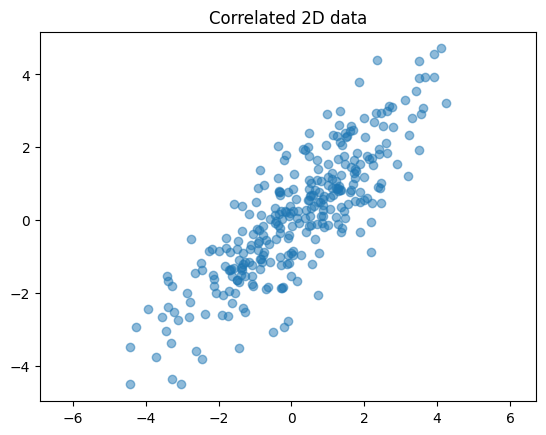

In [26]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Create 2D data with strong correlation
mean = [0, 0]
cov = [[3, 2.5],
       [2.5, 3]]

X = np.random.multivariate_normal(mean, cov, 300)

plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.title("Correlated 2D data")
plt.axis("equal")
plt.show()

## Step 2: Center the Data

PCA requires zero-mean data.

Centering ensures covariance captures variance structure rather than location.

In [27]:
X_centered = X - np.mean(X, axis=0)

## Step 3: Compute Covariance Matrix

The covariance matrix captures how features vary together.
Its eigenvectors define principal directions.

In [28]:
cov_matrix = np.cov(X_centered.T)
cov_matrix

array([[3.07322581, 2.57092246],
       [2.57092246, 3.06230562]])

## Step 4: Eigen-Decomposition

We compute eigenvalues and eigenvectors of the covariance matrix.

Eigenvalues → magnitude of variance  
Eigenvectors → directions of variance

In [29]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues, eigenvectors

(array([0.49683745, 5.63869397]),
 array([[ 0.70635551, -0.70785725],
        [-0.70785725, -0.70635551]]))

### Interpretation

The first eigenvalue is significantly larger than the second.

This indicates the data has strong intrinsic 1D structure.

## Step 5: Projection Onto First Principal Component

Each data point x is projected onto w₁:

z = w₁ᵀ x

This reduces dimensionality from 2D → 1D.

In [30]:
# Sort eigenvalues and eigenvectors
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# First principal component
w1 = eigenvectors[:, 0]

# Project data onto first PC
X_pca_1d = X_centered @ w1

X_pca_1d[:5]

array([ 4.33781788,  2.49747565,  4.57952572,  2.42849022, -0.04131094])

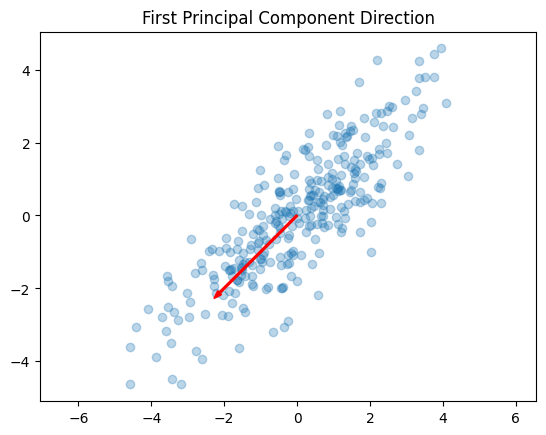

In [31]:
# Visualize projection direction

plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.3)

# Plot first principal component vector
origin = np.array([0,0])
scale = 3  # scaling for visualization

plt.arrow(0, 0,
          w1[0] * scale,
          w1[1] * scale,
          color='red',
          width=0.05)

plt.title("First Principal Component Direction")
plt.axis("equal")
plt.show()

## Step 6: Reconstruction From 1D Representation

Reconstruction formula:

x̂ = (w₁ᵀ x) w₁

All reconstructed points lie on the span of w₁.
Reconstruction error equals discarded eigenvalue.

Average reconstruction error: 0.49518132891060174


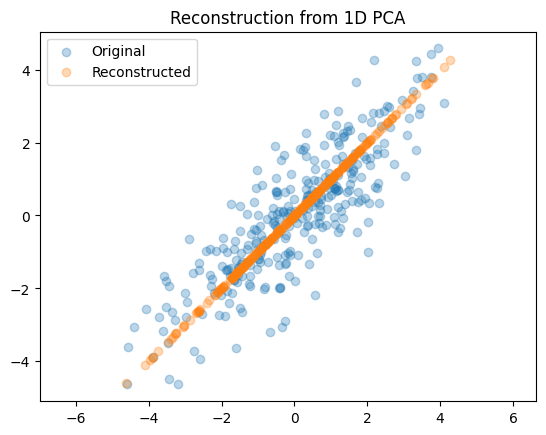

In [38]:
# Reconstruct back to 2D
X_reconstructed = np.outer(X_pca_1d, w1)

reconstruction_error = np.mean(
    np.sum((X_centered - X_reconstructed) ** 2, axis=1)
)

print("Average reconstruction error:", reconstruction_error)

plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.3, label="Original")
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1],
            alpha=0.3, label="Reconstructed")

plt.legend()
plt.axis("equal")
plt.title("Reconstruction from 1D PCA")
plt.show()

### Observation

Reconstructed points lie exactly on a straight line.
This line is the optimal 1D approximation of the dataset.

## Step 7: PCA via Singular Value Decomposition (SVD)

Instead of eigen-decomposition of Σ,
we directly compute:

X = U Σ Vᵀ

Columns of V are principal components.
Singular values squared correspond to covariance eigenvalues.

SVD is numerically more stable than eigendecomposition of XᵀX.

In [33]:
# PCA using SVD

U, S, Vt = np.linalg.svd(X_centered)

# Principal directions
principal_components = Vt.T

## Step 8: Explained Variance Ratio

Explained variance ratio:

λᵢ / Σ λⱼ

This measures how much information each principal component preserves.

In [34]:
# Explained variance
explained_variance = (S ** 2) / (len(X_centered) - 1)

explained_variance_ratio = explained_variance / explained_variance.sum()

explained_variance_ratio

array([0.91902291, 0.08097709])

## Step 9: Scree Plot

The scree plot visualizes cumulative explained variance.

Sharp rise → low intrinsic dimension  
Gradual rise → high intrinsic dimension

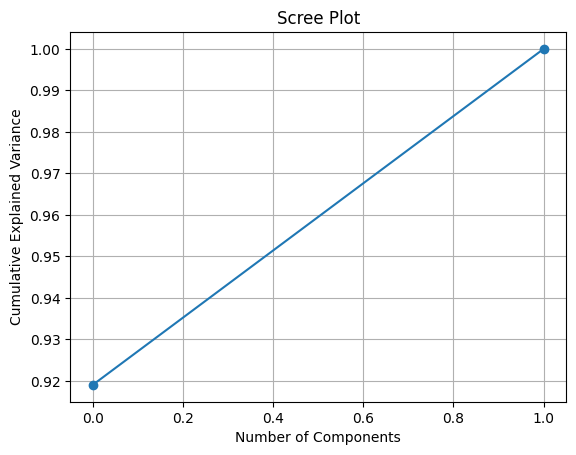

In [35]:
# Compute cumulative explained variance

cumulative_variance = np.cumsum(explained_variance_ratio)

plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

## Step 10: Automatic Component Selection

We choose the smallest k such that:

Cumulative variance ≥ 95%

This balances bias–variance tradeoff.

In [36]:
# Choose k automatically for 95% variance
k = np.argmax(cumulative_variance >= 0.95) + 1
print("Number of components for 95% variance:", k)

Number of components for 95% variance: 2


## Final Insights

• PCA finds orthogonal directions of maximum variance  
• Eigenvalues quantify variance preserved in each direction  
• Reconstruction error equals sum of discarded eigenvalues  
• PCA performs optimal linear dimensionality reduction  
• SVD provides numerically stable implementation  
• This dataset has intrinsic dimension ≈ 1  

Dimensionality reduction succeeds because variance spectrum decays sharply.

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_centered)

pca.explained_variance_ratio_

array([0.91902291, 0.08097709])

### Validation

Results match our manual PCA implementation.